In [4]:
zones = {
    "takeoff": ["W1", "W2", "W3", "W4"],
    "mid":     ["W5", "W6", "W7", "W8"],
    "landing": ["W9", "W10", "W11", "W12"]
}

wind_features = ["Speed", "Tangent", "Cross", "Turbulence"]

In [3]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

In [5]:
def interpolate_curve_by_x(curve):
    """
    Interpolates a 3D curve by x-coordinate (samplede at integer values) and returns (x, y, z),
    keeping the original start and end points exactly.

    Args:
        curve : array-like of shape (N, 3)
            Each row is [x, y, z].

    Returns:
        result : ndarray of shape (M, 3)
            Interpolated coordinates at integer x plus original endpoints.
    """

    curve = np.asarray(curve, dtype=float)
    if curve.ndim != 2 or curve.shape[1] != 3:
        raise ValueError("Data has the wrong shape")

    x = curve[:, 0]
    y = curve[:, 1]
    z = curve[:, 2]    

    x_new = np.arange(np.ceil(x.min()) + 0, np.floor(x.max()) + 1)

    #def f_y(x): values = interp1d(x, y, kind="linear", bounds_error=False, fill_value="extrapolate") return values
    #def f_z(x): values = interp1d(x, z, kind="linear", bounds_error=False, fill_value="extrapolate") return values
    
    f_y =  interp1d(x, y, kind="linear", bounds_error=False, fill_value="extrapolate")
    f_z = interp1d(x, z, kind="linear", bounds_error=False, fill_value="extrapolate")

    if len(x_new) > 0 :# or x[-1] != x_new[-1]:
        y_new = f_y(x_new)
        z_new = f_z(x_new)
        result = np.vstack([curve[0], np.column_stack((x_new, y_new, z_new)), curve[-1]])
    else:
        result = curve

    return result

In [6]:
#Zaenkrat opustim idejo, ker je funkcija slabša, oz. razdaljo izmeri še večjo. Quad pa skoraj
#nima vpliva nanj.

def interpolate_curve_by_arclength(curve, num_points=None):
    """
    Interpolates a 3D curve by arc length.

    Args:
        curve : array-like of shape (N, 3)
        num_points : int or None
            If None, keeps original number of points.

    Returns:
        ndarray of shape (num_points, 3)
    """
    curve = np.asarray(curve, dtype=float)

    if curve.ndim != 2 or curve.shape[1] != 3:
        raise ValueError("curve must be (N, 3)")

    diffs = np.diff(curve, axis=0)
    seg_lengths = np.linalg.norm(diffs, axis=1)

    s = np.concatenate([[0], np.cumsum(seg_lengths)])

    if num_points is None:
        num_points = len(curve)

    s_new = np.linspace(0, s[-1], num_points)

    fx = interp1d(s, curve[:, 0], kind="linear")
    fy = interp1d(s, curve[:, 1], kind="linear")
    fz = interp1d(s, curve[:, 2], kind="linear")

    result = np.vstack(np.column_stack((fx(s_new), fy(s_new), fz(s_new))))

    return result

In [7]:
def error_fun(curveA, curveB):
    curve1 = interpolate_curve_by_x(curveA)
    curve2 = interpolate_curve_by_x(curveB)

    #curve1 = interpolate_curve_by_arclength(curveA)
    #curve2 = interpolate_curve_by_arclength(curveB)

    if len(curve1) < len(curve2):
        longer = curve2
        shorter = curve1
    else:
        longer = curve1
        shorter = curve2

    longer1 = longer[:len(shorter)]
    shorter1 = shorter

    pad_len = len(longer) - len(shorter)
    if pad_len > 0:
        last_point = shorter[-1][None, :]   #seznam ene zadnje točke
        pad = np.repeat(last_point, pad_len, axis=0)    #ponovimo
        shorter2 = pad
        longer2 = longer[len(shorter):]

        diffs = np.vstack([longer1 - shorter1, longer2 - shorter2])
    else:
        diffs = longer1 - shorter1

    dists = np.linalg.norm(diffs, axis=1)
    return np.mean(dists)

In [139]:
a = np.vstack([[0, 0, 3], [0, 1, 5]])
a

array([[0, 0, 3],
       [0, 1, 5]])

In [140]:
dists = np.linalg.norm(a, axis=1)
dists

array([3.        , 5.09901951])

In [141]:
np.mean(dists)

np.float64(4.049509756796392)

In [142]:
def preprocess_flight_normalized(df, step=0.05):
    """
    Preprocess a normalized flight dataframe (already interpolated) to generate states (X), observations (Y), and controls (U).
    
    Args:
        df (pd.DataFrame): Normalized flight dataframe (fixed time step).
        step (float): Time step between rows (used for derivatives).
        
    Returns:
        states (np.ndarray): State matrix [time_steps, state_dim].
        observations (np.ndarray): Observation matrix [time_steps, obs_dim].
        controls (np.ndarray): Control matrix [time_steps, control_dim].
    """

    df.columns = df.columns.str.strip()   #izloči imena stolpcev
    df = df.iloc[1:]
    
    df = df.ffill().bfill()   #back fill za manjkajoče vrednosti
    
    x = df["X [m]"].to_numpy()   #save values
    y = df["Y [m]"].to_numpy()
    z = df["Z [m]"].to_numpy()
    
    dt = step
    #vx = np.gradient(x, dt)   #gradient za hitrost
    vx = df.get("Speed hor. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)
    vy = np.gradient(y, dt)
    #vz = np.gradient(z, dt)
    vz = df.get("Speed vert. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    speed = df.get("Speed resulting [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    opening = df.get("Opening Angle [°]", pd.Series([0]*len(x))).to_numpy()
    roll_L = df.get("Roll Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    roll_R = df.get("Roll Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_L = df.get("Yaw Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_R = df.get("Yaw Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    stall_L = df.get("Stalling Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    stall_R = df.get("Stalling Angle Right [°]", pd.Series([0]*len(x))).to_numpy()

    states = np.stack([x, y, z, vx, vy, vz, speed, opening, roll_L, roll_R, yaw_L, yaw_R, stall_L, stall_R], axis=1)   #zgradimo state vector X

    height = df.get("Height above ground [m]", pd.Series([0]*len(x))).to_numpy()

    observations = np.stack([x, y, z, height], axis=1)   #zgradimo observation vector Y

    zone_feature_avgs = []
    values = []
    cols = []

    #print(vz)
    #print(speed)

    #for feature in wind_features:
    #    for sensor_numb in range(12):
    #        sensor = f"W{sensor_numb + 1}"
    #        cols.append(f"{sensor}_{feature}")
    #        #print(cols)
    #for col in cols:
    #    val = df.get(col, pd.Series([0]*len(x))).to_numpy() 
    #    values.append(val)
    #
    #controls = np.stack(values, axis=1)  # shape: (time_steps, 12)

    for feature in wind_features:
        for zone, sensors in zones.items():
            cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
            avg_feature = df[cols].mean(axis=1).to_numpy()
            zone_feature_avgs.append(avg_feature)
    
    controls = np.stack(zone_feature_avgs, axis=1)  # shape: (time_steps, 12)
    
    return states, observations, controls


In [143]:
import os
import pandas as pd
import numpy as np

normalized_folder = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\simulation\2024_03_Planica_12_winds\cleaned\normalized'
#combined_output = os.path.join(normalized_folder, "combined_dataset.npz")
file_names = []

X_list, Y_list, U_list = [], [], []

for filename in os.listdir(normalized_folder):
    if filename.endswith('.csv'):
        file_path = os.path.join(normalized_folder, filename)
        df = pd.read_csv(file_path)

        X_state, Y_obs, U_ctrl = preprocess_flight_normalized(df)

        X_list.append(X_state)
        Y_list.append(Y_obs)
        U_list.append(U_ctrl)
        file_names.append(filename)

        #if np.any(np.isnan(X_state)):
        #    print(f"NaN values in {filename}")

        print(f"Processed {filename} -> X:{X_state.shape}, Y:{Y_obs.shape}, U:{U_ctrl.shape}")

# Save combined dataset
#np.savez(combined_output, X=np.array(X_list, dtype=object), Y=np.array(Y_list, dtype=object), U=np.array(U_list, dtype=object))
#print(f"\nCombined dataset saved to {combined_output}")


Processed 999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned_normalized.csv -> X:(135, 14), Y:(135, 4), U:(135, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102742_C_OfficialResults_cleaned_normalized.csv -> X:(131, 14), Y:(131, 4), U:(131, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102831_C_OfficialResults_cleaned_normalized.csv -> X:(145, 14), Y:(145, 4), U:(145, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102832_C_OfficialResults_cleaned_normalized.csv -> X:(139, 14), Y:(139, 4), U:(139, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102833_C_OfficialResults_cleaned_normalized.csv -> X:(136, 14), Y:(136, 4), U:(136, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102834_C_OfficialResults_cleaned_normalized.csv -> X:(132, 14), Y:(132, 4), U:(132, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102835_C_OfficialResults_cleaned_normalized.csv -> X:(156, 14), Y:(156, 4), U:(156, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102836_C_OfficialResults

### train / test split

In [144]:
from sklearn.model_selection import train_test_split

# Train/test split along time dimension
X_train, X_test, Y_train, Y_test, U_train, U_test = train_test_split(
    X_list, Y_list, U_list, test_size=0.2, random_state=42)

In [145]:

# Prepare stacked data for system identification
X_t = np.vstack([seq[:-1] for seq in X_train])      # state at time t   
X_next = np.vstack([seq[1:] for seq in X_train])    # state at time t+1  #spustimo 0. da zamaknemo
U_t = np.vstack([u[:-1] for u in U_train])          # control at time t  - matchamo s X_t
Y_t = np.vstack([obs[:-1] for obs in Y_train])      # observation at time t

print(f"X_t: {X_t.shape}, X_next: {X_next.shape}, U_t: {U_t.shape}, Y_t: {Y_t.shape}")


X_t: (21948, 14), X_next: (21948, 14), U_t: (21948, 12), Y_t: (21948, 4)


In [146]:
# Build regression matrix
Phi = np.hstack([X_t, U_t])   # [x_t | u_t]...skupaj sestavimo v eno matriko

Theta, _, _, _ = np.linalg.lstsq(Phi, X_next, rcond=None)  #rešitev po MNK (stabilna verzija)
    #output MNK: matrika A in B, reziduali, rank (A in B), singularnosti (vse razen 1. ignoriramo)
    #ponovimo mnk za vektor, za vsako vrstico v output matriki...MNK za matrike

In [147]:
# Extract A and B
state_dim = X_t.shape[1]
control_dim = U_t.shape[1]
A = Theta[:state_dim, :].T   #prvih state_dim vrstic, vsi stolpci
B = Theta[state_dim:, :].T   #the rest (control_dim)

print("A shape:", A.shape)
print("B shape:", B.shape)

A shape: (14, 14)
B shape: (14, 12)


In [148]:
Phi_y = np.hstack([X_t, U_t])
Theta_y, _, _, _ = np.linalg.lstsq(Phi_y, Y_t, rcond=None)

obs_dim = Y_t.shape[1]
C = Theta_y[:state_dim, :].T
D = Theta_y[state_dim:, :].T

print("C shape:", C.shape)
print("D shape:", D.shape)


C shape: (4, 14)
D shape: (4, 12)


In [149]:
def simulate_trajectory(x0, U_seq, A, B):
    """
    Simulate trajectory using learned A, B.
    x0: initial state (shape: [state_dim])
    U_seq: control inputs (shape: [T, control_dim])
    """
    X_sim = [x0]  #shrani initial state
    for u in U_seq:                     # @...matrix/vector multiplication
        x_next = A @ X_sim[-1] + B @ u  #Zračuna naslednji korak
        X_sim.append(x_next)            #shrani
    return np.array(X_sim)

# Example: take first flight  (spreminjaš 1. [] pri obeh)
x0 = X_test[0][0]      # first sublist first element    a.k.a. first data row for first flight
U_seq = U_test[0]      # controls for that flight
X_sim = simulate_trajectory(x0, U_seq, A, B)

print("Simulated trajectory shape:", X_sim.shape)


Simulated trajectory shape: (130, 14)


In [150]:
A @ x0

array([ 1.40194720e+00,  3.89440661e-05, -2.56151173e-01,  2.67449635e+02,
       -1.49163325e-02, -4.70907377e+01,  2.71877981e+02,  2.53041975e+00,
       -1.10284302e+00,  1.64797862e+00,  1.22016702e+00, -1.30317526e+00,
       -9.84491177e+00, -9.68727988e+00])

In [151]:
B @ U_seq[0]

array([-2.76209125e-03,  8.12160475e-05, -3.44137140e-04, -3.36377615e-03,
        4.05143715e-02,  5.56232189e-02,  2.28215040e-03, -3.46188620e-01,
       -1.06995094e-01,  1.99055220e-02, -1.44206262e-01,  1.98668062e-01,
       -3.30319610e-01, -2.74617472e-01])

## stare funkcije za napako

Težko določit uredu segment, oz. če bi vzeli celotno krivuljo. I also think da je blo quite časovno zahtevno.

In [152]:
def point_segment_distance(p, a, b):
    """Distance from point p to segment a-b, and projection point"""
    ap = p-a
    ab = b-a
    denom = np.dot(ab, ab)
    if denom == 0:
        return np.linalg.norm(p-a), a
    t = np.dot(ap, ab) / denom #produkt deljen z normo
    t = np.clip(t, 0, 1)
    proj = a + t* ab
    return np.linalg.norm(p-proj), proj

In [153]:
def curve_projection_distance(curve1, curve2):
    """Mean distance from points in curve1 to curve2's segments"""
    distances = []
    for p in curve1:
        min_dist = float("inf")
        for i in range(len(curve2) - 1):
            dist, _ = point_segment_distance(p, curve2[i], curve2[i + 1])
            if dist < min_dist:
                min_dist = dist
        distances.append(min_dist)
    return np.mean(distances)

In [154]:
def bidirectional_curve_distance(curve_a, curve_b):
    """Symetric bidirectionall mean projection distance"""
    d1 = curve_projection_distance(curve_a, curve_b)
    d2 = curve_projection_distance(curve_b, curve_a)
    return (d1 + d2) / 2

In [155]:
def curve_length (curve):
    return np.sum(np.linalg.norm(np.diff(curve, axis=0), axis=1))

def penalized_bidirectional_distance(curve_a, curve_b, length_weight = 0.5):
    shape_dist = bidirectional_curve_distance(curve_a, curve_b)
    len_a = curve_length(curve_a)
    len_b = curve_length(curve_b)
    length_diff = abs(len_a - len_b)
    return shape_dist + length_weight * length_diff

In [156]:
#from scipy.spatial import cKDTree
#
#def penalized_bidirectional_distance(A, B, penalty_factor=0.5):
#    tree_A = cKDTree(A)
#    tree_B = cKDTree(B)
#
#    dist_A_to_B, _ = tree_B.query(A)
#    dist_B_to_A, _ = tree_A.query(B)
#
#    mean_A_to_B = np.mean(dist_A_to_B)
#    mean_B_to_A = np.mean(dist_B_to_A)
#
#    return mean_A_to_B + penalty_factor * mean_B_to_A


## Plotting

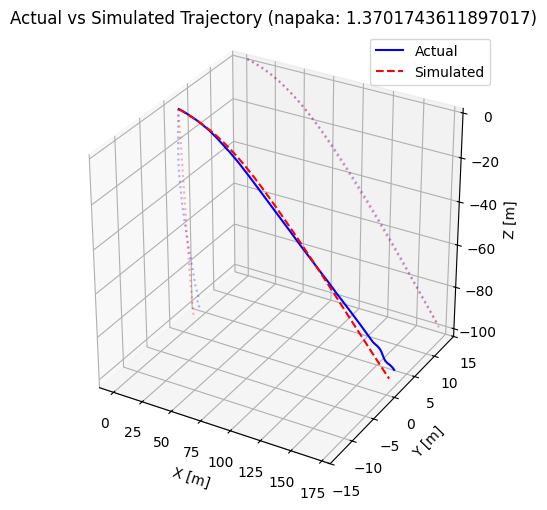

In [157]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

    #(spreminjaš 1. [] v 1. vrstici)
actual = X_test[0][:, :3]   #vzame X,Y,Z iz [x, y, z, vx, vy, vz]
sim = X_sim[:, :3]          # same iz simulacije

Xa = actual[:,0]
Ya = actual[:,1]
Za = actual[:,2]

Xs = sim[:,0]
Ys = sim[:,1]
Zs = sim[:,2]

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

ax.plot3D(Xa, Ya, Za, label="Actual", color="blue")
ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")

# Ground projections
ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')

ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')

napaka = penalized_bidirectional_distance(actual, sim, 0.5)

ax.set_title(f"Actual vs Simulated Trajectory (napaka: {napaka})")
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]")
ax.legend()
ax.set_box_aspect([1,1,1])
ax.set_ylim(-15, 15)

plt.legend()
plt.tight_layout()
plt.show()


In [158]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

def plot(X_seq, X_sim, j, name):
    """
    Plot actual vs simulated trajectory in 3D with projections.
    Args:
        X_seq (ndarray): ground truth state sequence (T, state_dim)
        X_sim (ndarray): simulated state sequence (T, state_dim)
        j (int): index of jump
        name (str): identifier for saving plots """

    save_dir = f"plots/{name}"
    os.makedirs(save_dir, exist_ok=True)

    
    actual = X_seq[:, :3]   #vzame X,Y,Z iz [x, y, z, vx, vy, vz]
    sim = X_sim[:, :3]          # same iz simulacije

    Xa, Ya, Za = actual[:,0], actual[:,1], actual[:,2]
    Xs, Ys, Zs = sim[:,0], sim[:,1], sim[:,2]
    
    #napaka = np.mean(np.linalg.norm(actual - sim, axis=1))
    napaka = error_fun(actual, sim)
    length = (Xs[-1]**2 + Ys[-1]**2 + Zs[-1]**2)**(1/2)
    length_a = (Xa[-1]**2 + Ya[-1]**2 + Za[-1]**2)**(1/2)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot3D(Xa, Ya, Za, label="Actual", color="blue")
    ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")


    # Ground projections
    ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')

    ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')


    ax.set_title(f"Actual vs Simulated Trajectory\n Error: {napaka:.3f}, Simulated length: {length:.1f},  Actual length: {length_a:.1f}")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.legend()
    ax.set_box_aspect([1,1,1])
    ax.set_ylim(-15, 15)

    plt.legend()
    #plt.tight_layout()

    filename = f"2SSM flight_simulation{j + 1}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300)
    plt.close(fig)
    #plt.show()


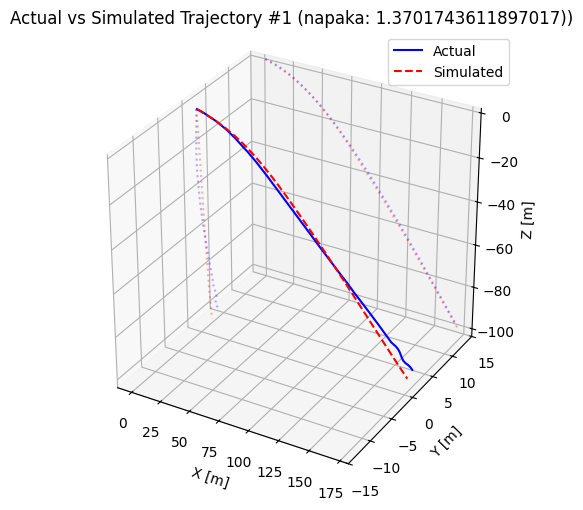

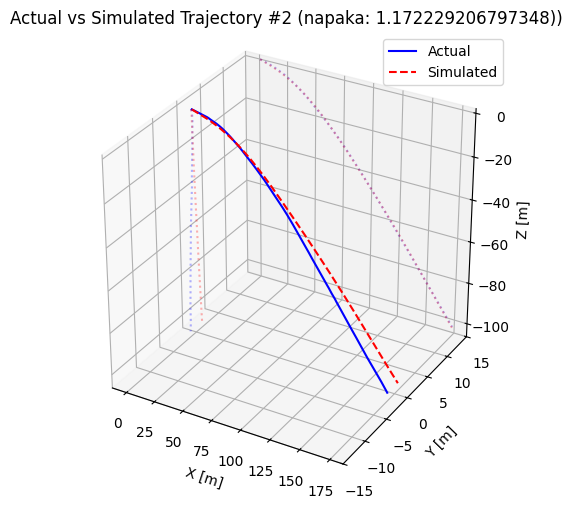

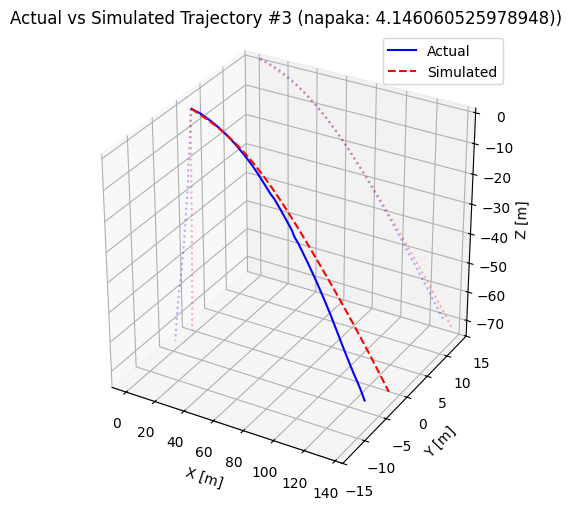

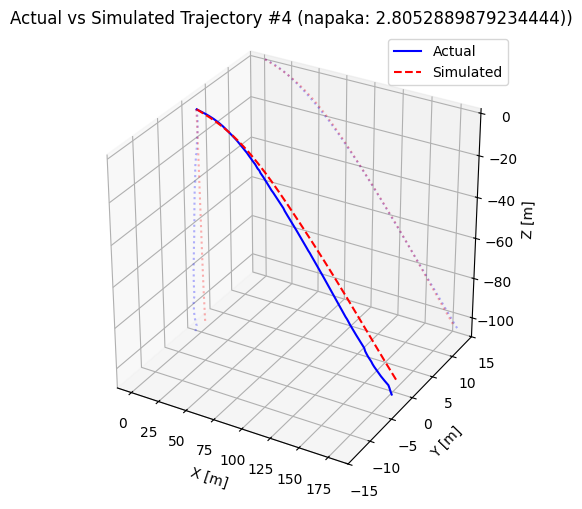

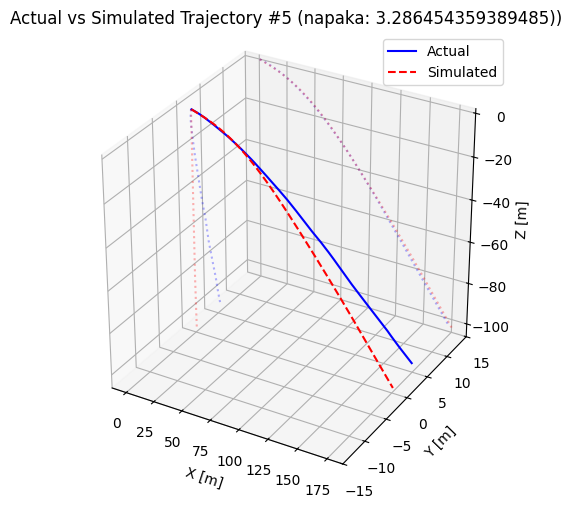

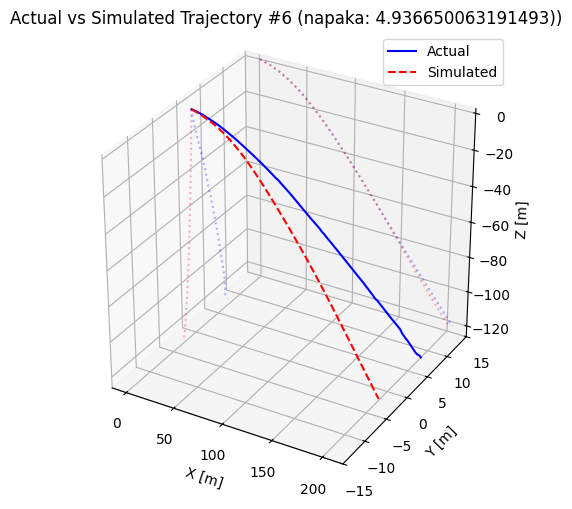

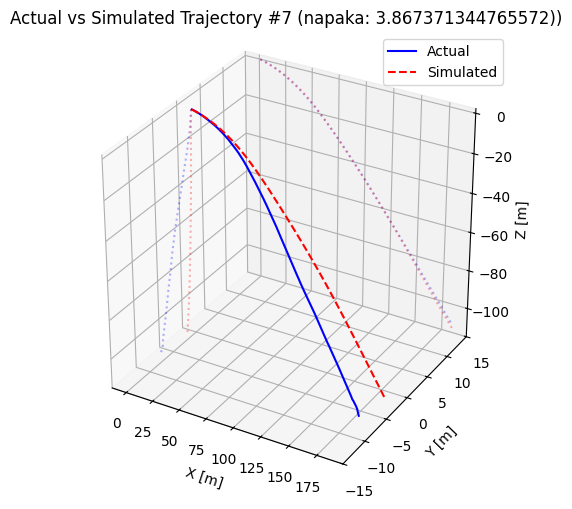

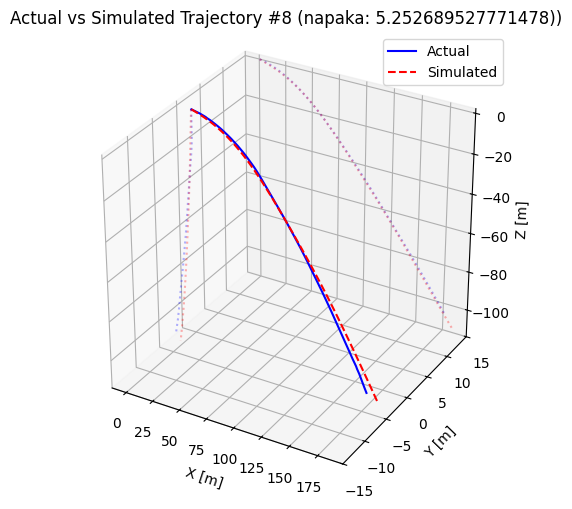

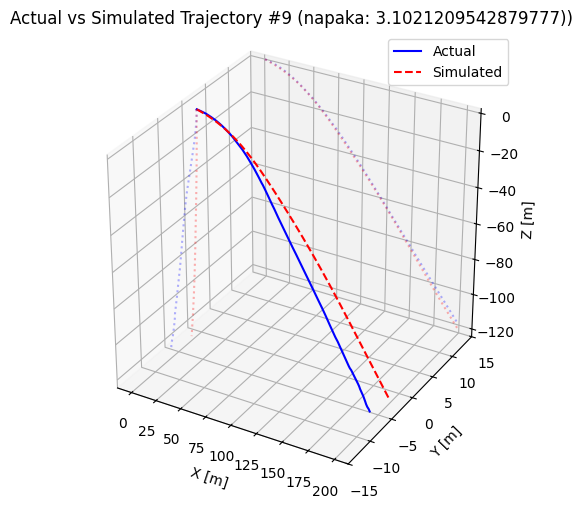

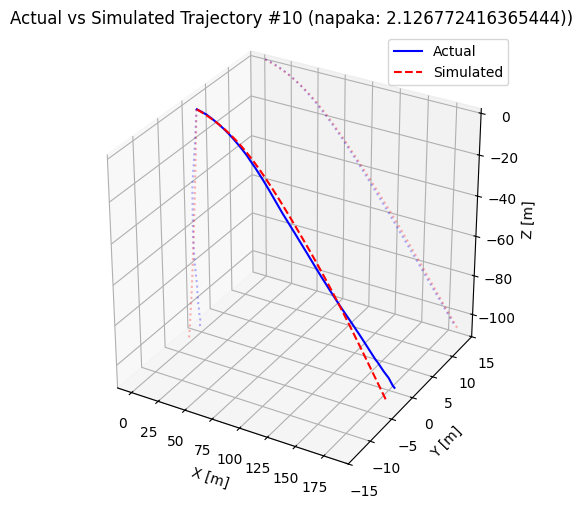

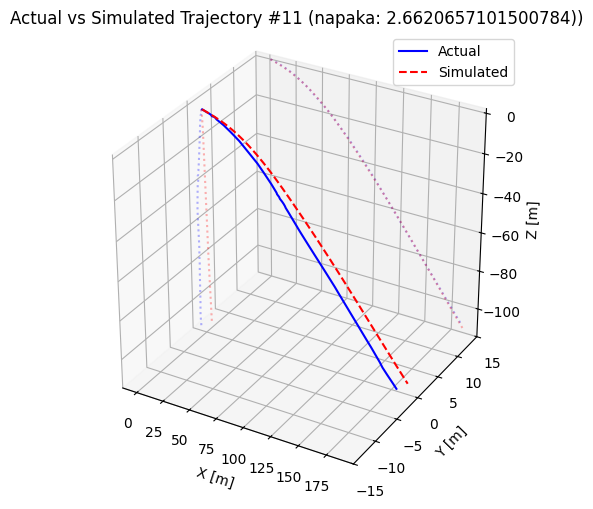

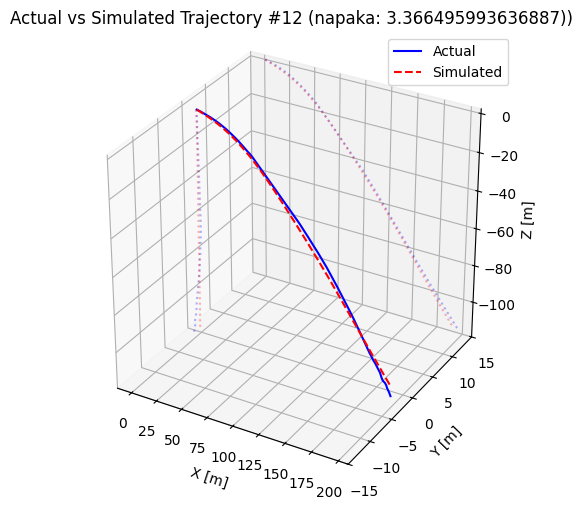

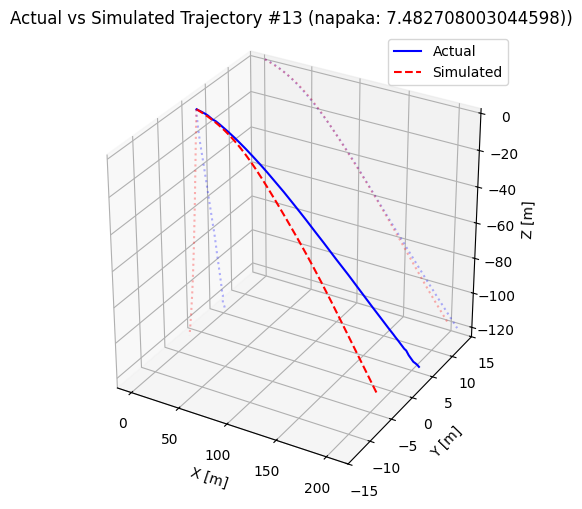

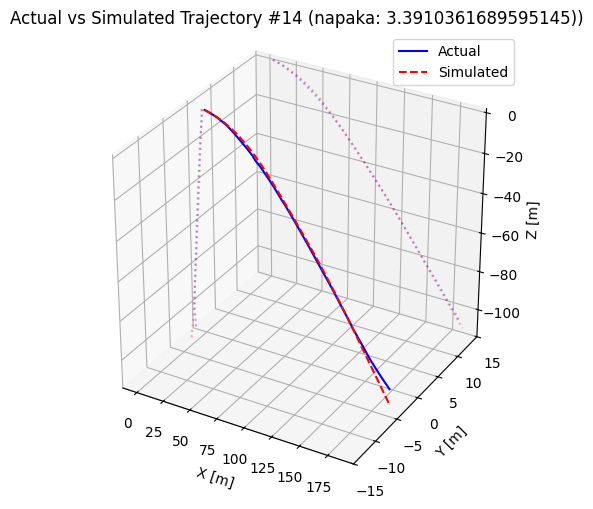

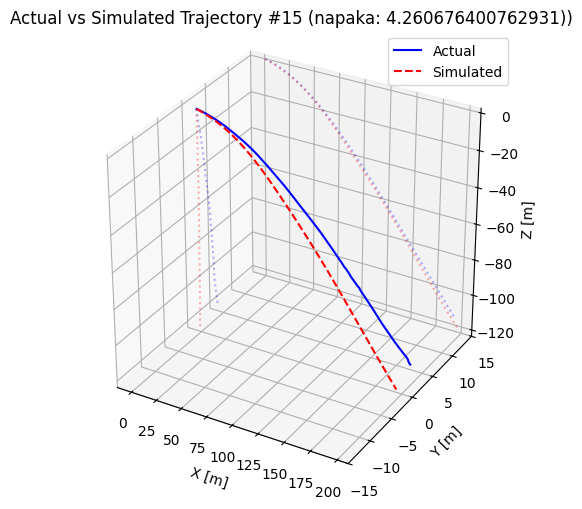

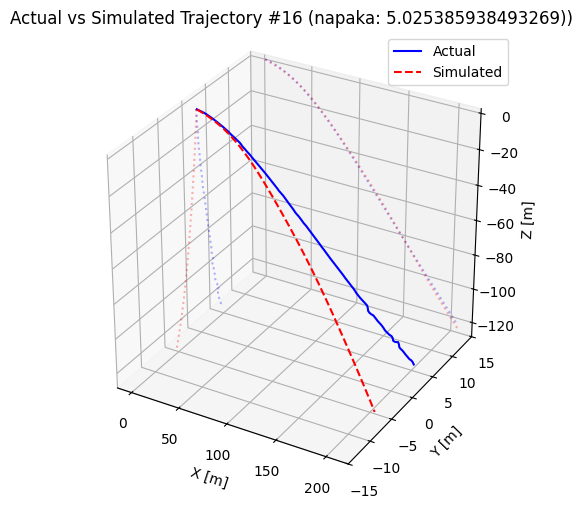

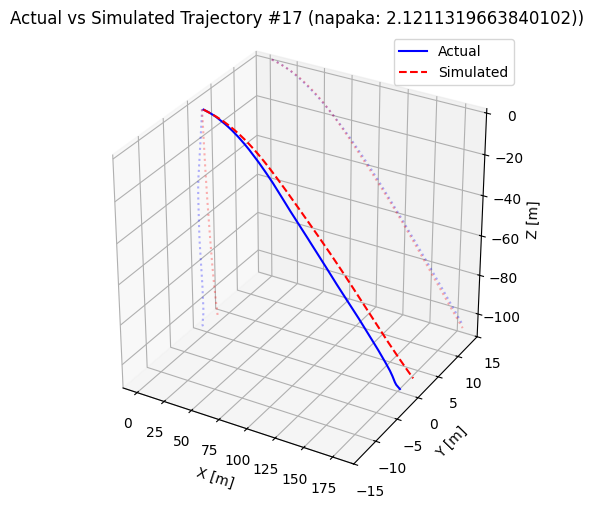

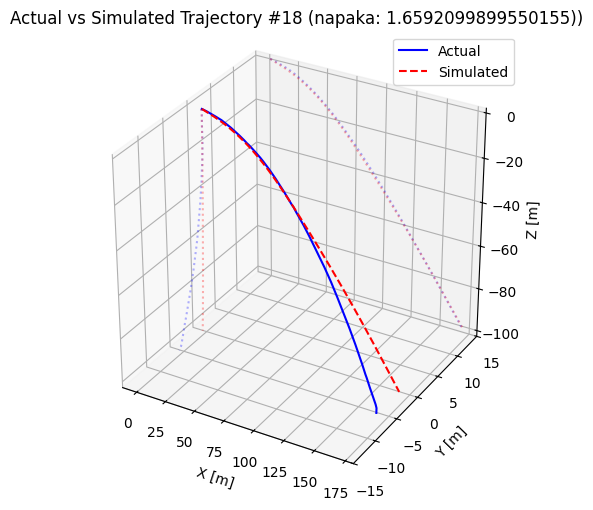

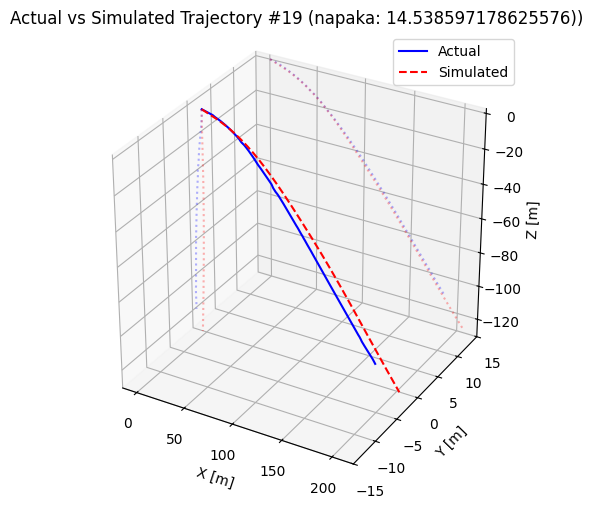

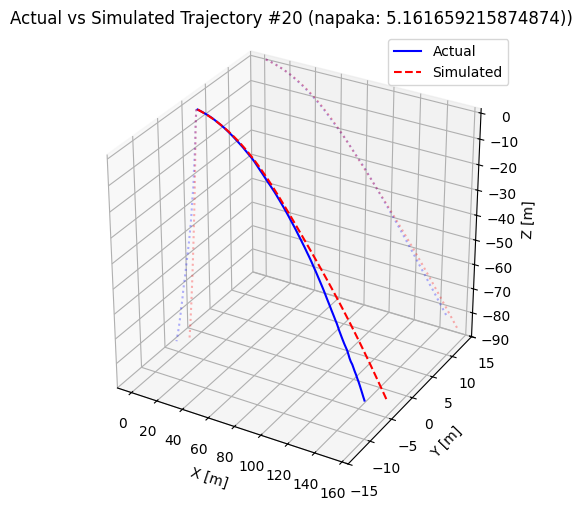

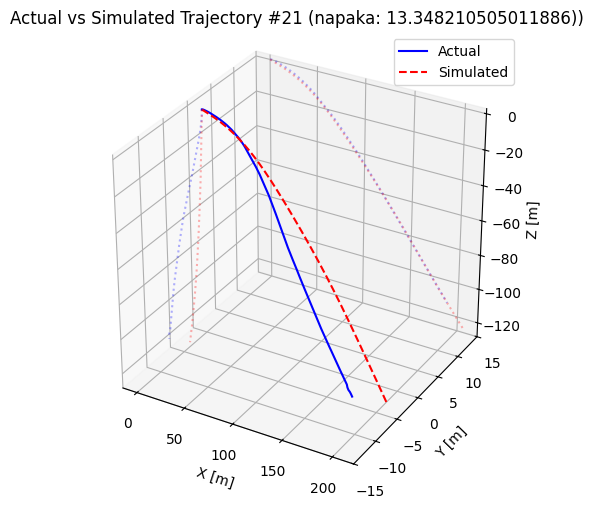

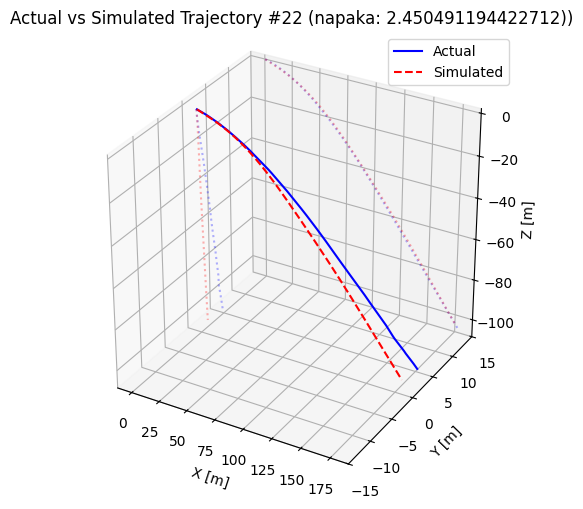

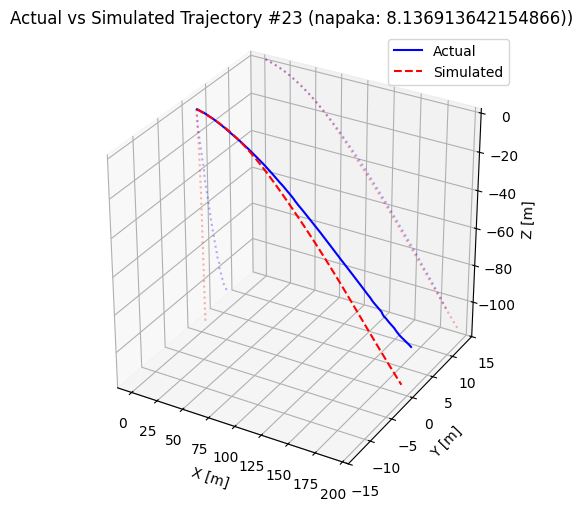

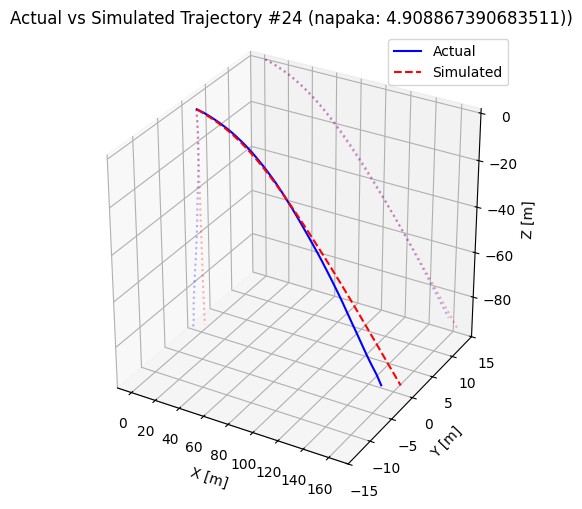

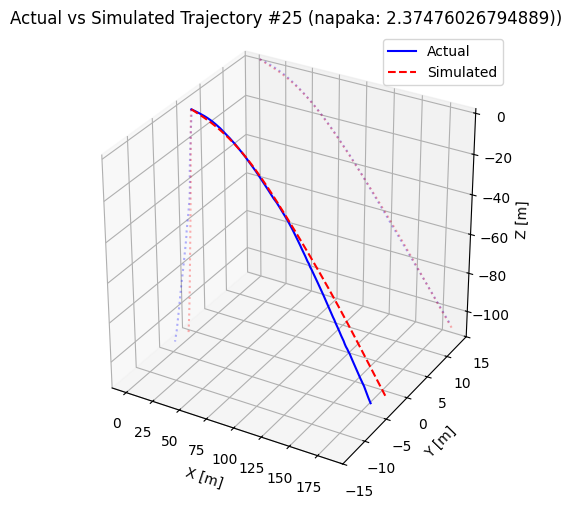

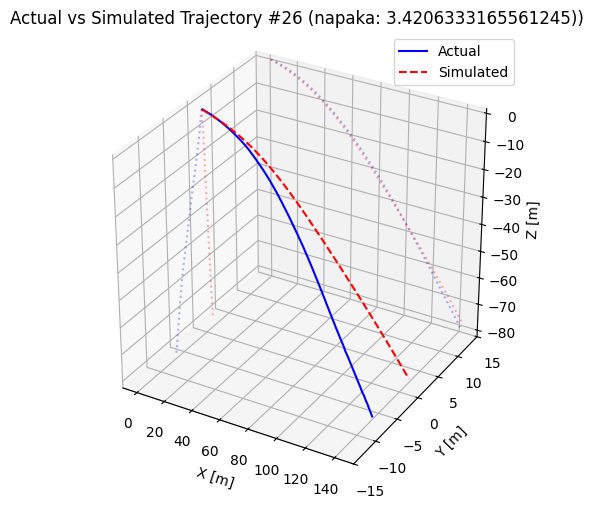

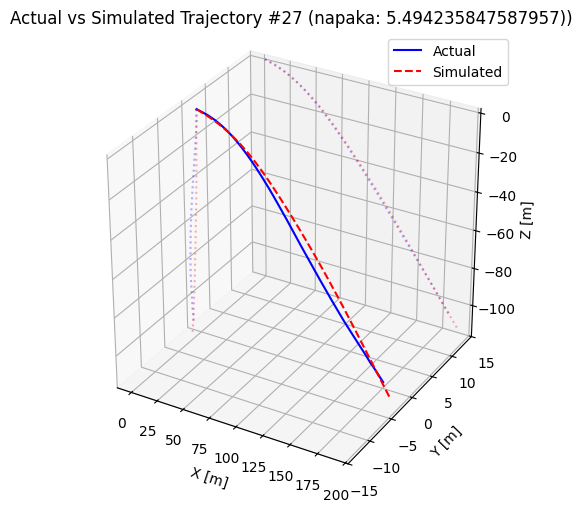

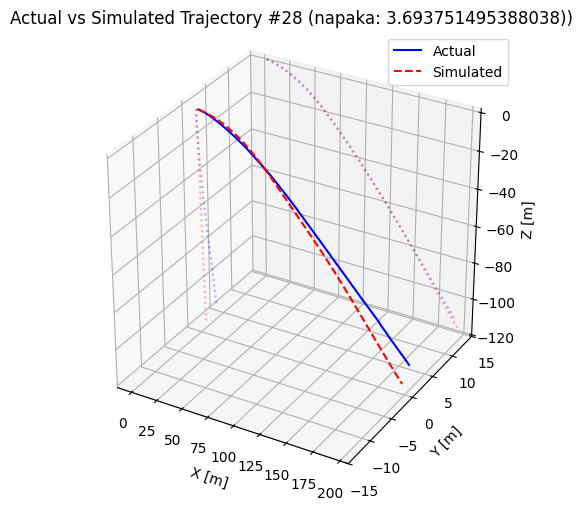

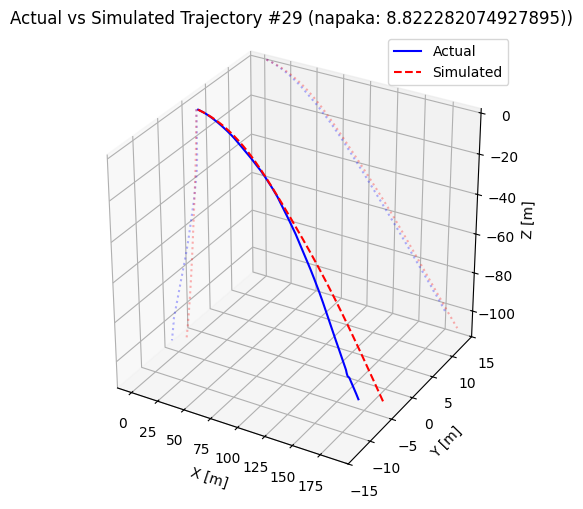

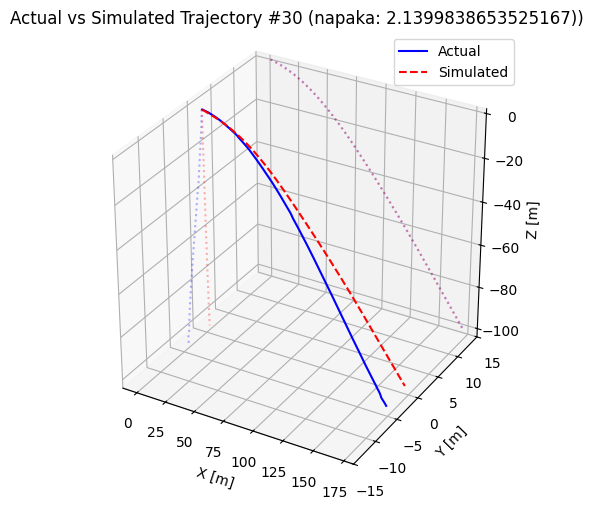

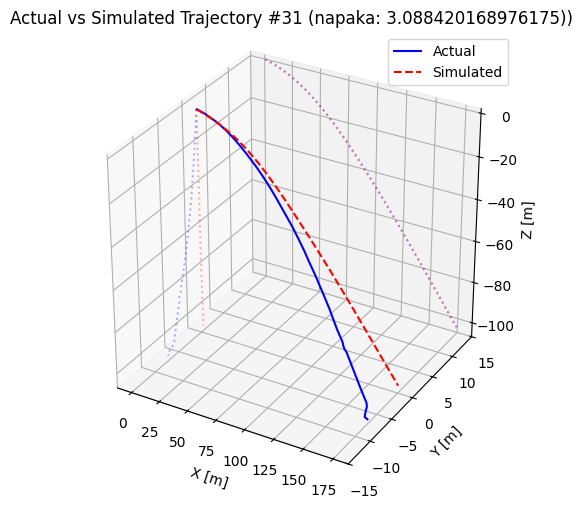

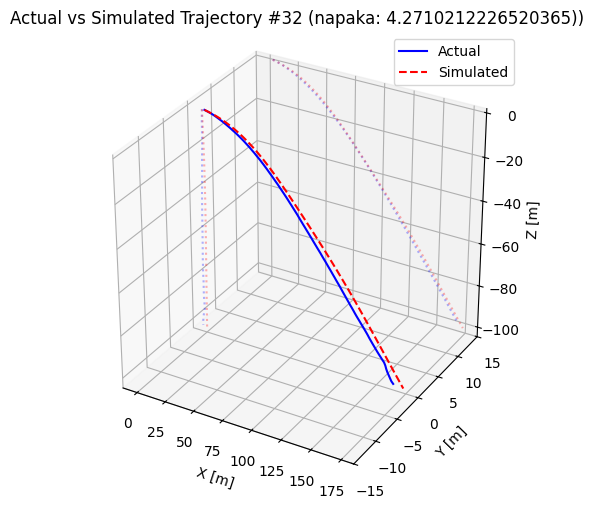

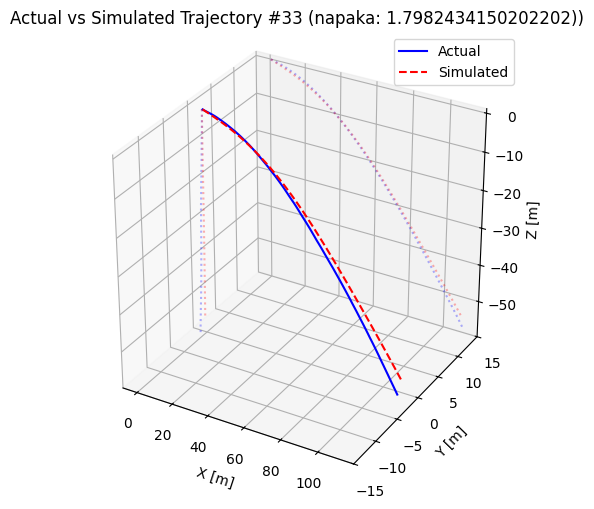

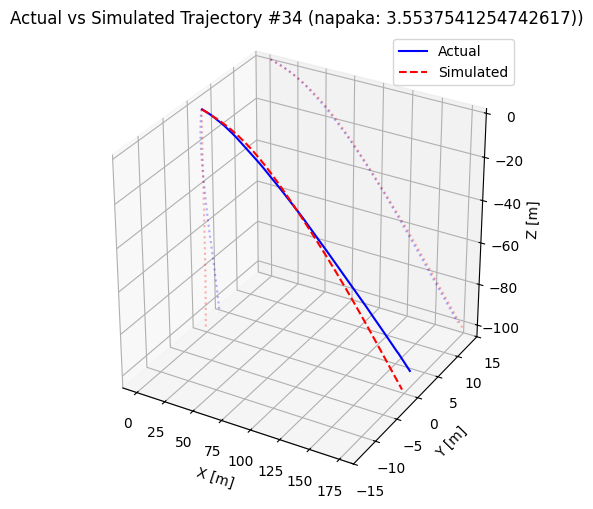

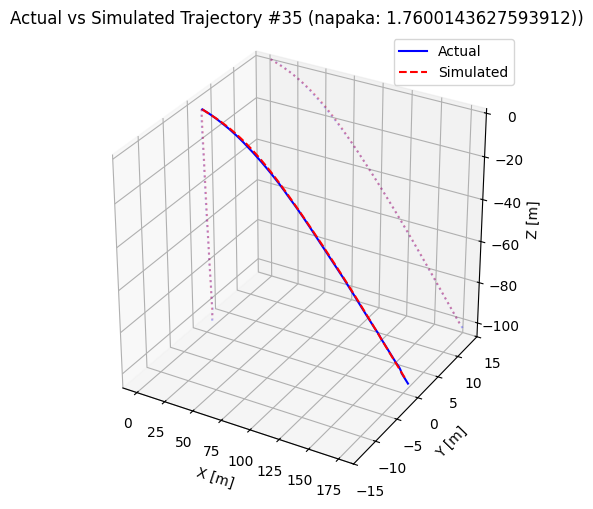

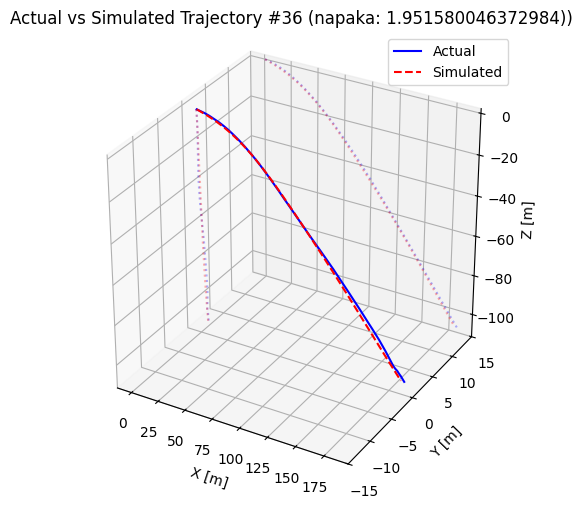

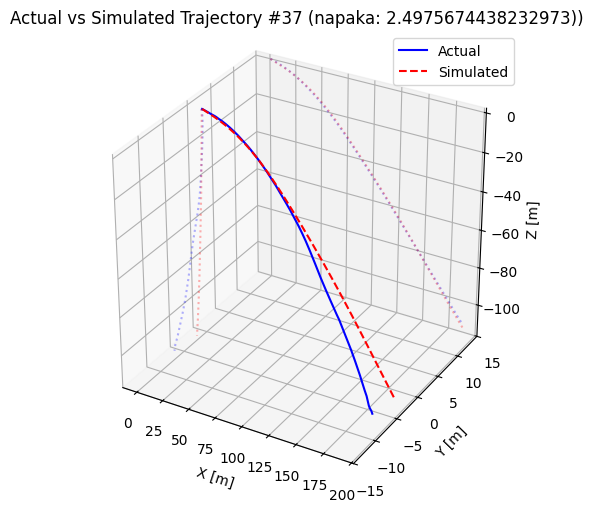

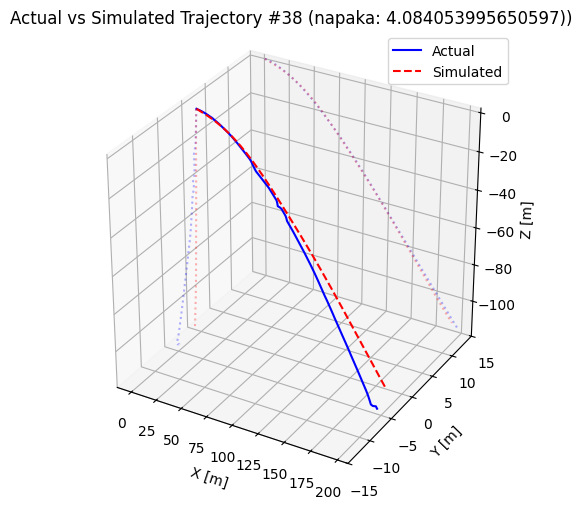

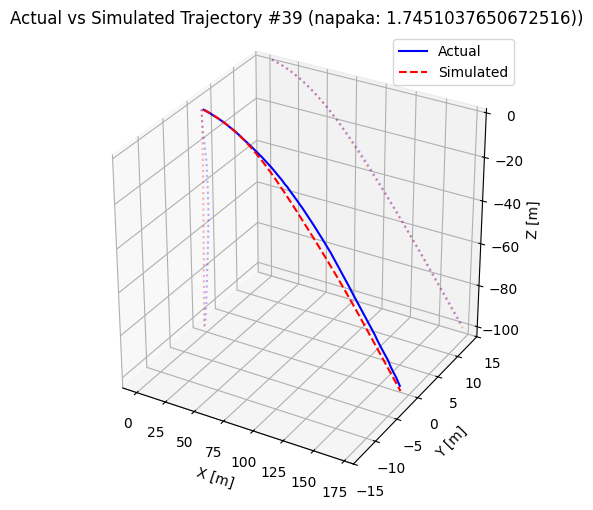

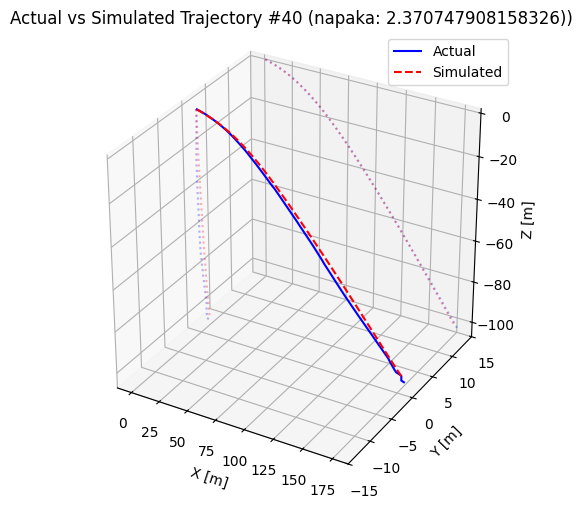

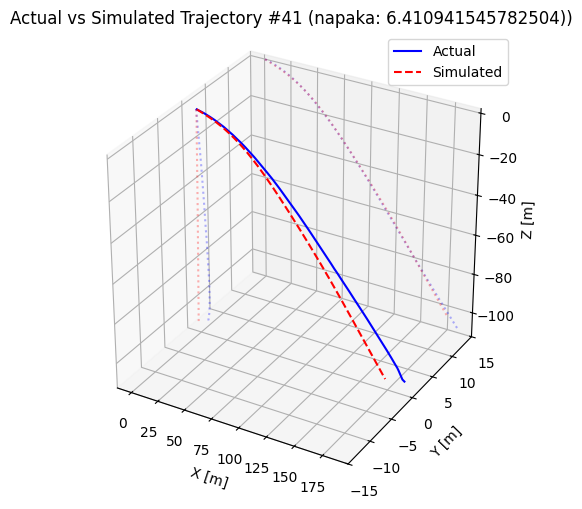

4.147715997885832


In [159]:

#save_dir = "plots/normalized_SSM"
#os.makedirs(save_dir, exist_ok=True)

napake = []

for idx in range(len(X_test)):

    jump_idx = idx

    x0 = X_test[jump_idx][0]    #0...std in 1...norm 
    U_seq = U_test[jump_idx]      # controls for that flight
    #X_sim = simulate(A_stable, B_new, b_new, x0, U_seq)
    X_sim = simulate_trajectory(x0, U_seq, A, B)


    actual = X_test[jump_idx][:, :3]
    sim = X_sim[:, :3]


    Xa = actual[:,0]
    Ya = actual[:,1]
    Za = actual[:,2]

    Xs = sim[:,0]
    Ys = sim[:,1]
    Zs = sim[:,2]

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot3D(Xa, Ya, Za, label="Actual", color="blue")
    ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")

    # Ground projections
    ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')

    ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')

    napaka = penalized_bidirectional_distance(actual, sim, 0.5)
    napake.append(napaka)

    ax.set_title(f"Actual vs Simulated Trajectory #{jump_idx + 1} (napaka: {napaka}))")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.legend()
    ax.set_box_aspect([1,1,1])
    ax.set_ylim(-15, 15)

    plt.legend()
    plt.tight_layout()

    #name = f"flight_simulation{jump_idx + 1}.png"
    #plt.savefig(os.path.join(save_dir, name), dpi=300)

    plt.show()
    
print(np.average(napake))

## leave-one-out cross-validation

In [160]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

def fit_ssm_cv(X_list, U_list, Y_list, n_splits=len(X_list), alpha=1e-3):
    """
    Fit an SSM model using K-fold cross-validation across jumps.

    Args:
        X_list, U_list, Y_list: lists of arrays (one per jump)
        n_splits (int): number of folds
        alpha (float): ridge regularization parameter

    Returns:
        avg_train_err, avg_test_err, models (list of (A,B,C,D) per fold)
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_errors, test_errors = [], []
    models = []

    for train_idx, test_idx in kf.split(X_list):

        X_t = np.vstack([seq[:-1] for i, seq in enumerate(X_list) if i in train_idx])
        X_next = np.vstack([seq[1:] for i, seq in enumerate(X_list) if i in train_idx])
        U_t = np.vstack([u[:-1] for i, u in enumerate(U_list) if i in train_idx])
        Y_t = np.vstack([y[:-1] for i, y in enumerate(Y_list) if i in train_idx])

        # Regression [X_next] ~ [X_t | U_t]
        Phi = np.hstack([X_t, U_t])
        ridge = Ridge(alpha=alpha, fit_intercept=False)     #ridge is just MNK z regularizacijo
                
        ridge.fit(Phi, X_next)
        Theta = ridge.coef_.T

        state_dim = X_t.shape[1]
        control_dim = U_t.shape[1]
        A = Theta[:state_dim, :].T
        B = Theta[state_dim:, :].T

        # Regression [Y_t] ~ [X_t | U_t]
        Phi_y = np.hstack([X_t, U_t])
        ridge_y = Ridge(alpha=alpha, fit_intercept=False)
        ridge_y.fit(Phi_y, Y_t)
        Theta_y = ridge_y.coef_.T

        obs_dim = Y_t.shape[1]
        C = Theta_y[:state_dim, :].T
        D = Theta_y[state_dim:, :].T

        models.append((A, B, C, D))

        train_sim = X_t @ A.T + U_t @ B.T
        train_err = np.mean(np.linalg.norm(train_sim[:, :3] - X_next[:, :3], axis=1))
        #train_err = penalized_bidirectional_distance(train_sim[::10], X_next[::10])
        train_errors.append(train_err)

        test_errs = []
        for j in test_idx:
            x0 = X_list[j][0]       #initial state...adjust it
            U_seq = U_list[j]
            X_seq = X_list[j]

            # simulate with learned model
            X_sim = [x0]
            for t in range(len(U_seq)-1):
                x_next = A @ X_sim[-1] + B @ U_seq[t]
                X_sim.append(x_next)
            X_sim = np.array(X_sim)

            test_err = error_fun(X_seq[:, :3], X_sim[:, :3])
            #test_err = np.mean(np.linalg.norm(X_seq[:, :3] - X_sim[:, :3], axis=1))
            #test_err = penalized_bidirectional_distance(X_seq[::10], X_sim[::10])
            test_errs.append(test_err)

            plot(X_seq, X_sim, j, "2-SSM")
        test_errors.append(np.mean(test_errs))

        print(train_err, np.mean(test_errs))
    

    return np.mean(train_errors), np.mean(test_errors), models


In [161]:
avg_train_err, avg_test_err, models = fit_ssm_cv(X_list, U_list, Y_list, n_splits=len(X_list), alpha=10)

print("average train error:", avg_train_err)
print("average test_error:", avg_test_err)

0.08228518555399049 0.86504636260056
0.08231891468218522 1.0448459225885842
0.0822287791476204 1.6011249837342574
0.08216739675198717 1.2252569445381232
0.08229182179058275 1.9899299941467383
0.08232717927214168 4.620143857235092
0.08229940071120098 2.5335773944124034
0.08223773206143821 0.8623730894331759
0.08226579450251009 2.0096895262408556
0.08226283214514195 1.1054753389739145
0.08224493162441446 1.5096405147694625
0.08193836819221369 1.187196433707611
0.08223200834470575 3.7297409040599465
0.08175584545325054 0.721681813981113
0.08226016616911001 2.4450755027008375
0.08225648263277309 3.0488860198575884
0.08226147393086708 1.9623723700525517
0.08196217149510317 1.5580979589933477
0.08171398845125134 2.321881752968025
0.08224384760077974 1.3220757244853591
0.08181530328162123 3.478982951811638
0.08219216657149966 1.5192544196495048
0.08224681031289516 2.238387099654621
0.08223570919861684 0.9741135042316882
0.08225626895060631 0.9879682653797734
0.08219598771090944 3.531181717593

## izolacija test

In [135]:
x0

array([ 4.30621118e-01,  0.00000000e+00, -8.14285714e-02,  2.67405970e+02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  9.93788820e-01,
       -1.29409938e+00,  1.73944099e+00,  4.69875776e-01, -5.25776398e-01,
       -1.11034161e+01, -1.08770186e+01])

In [148]:
y0 = np.zeros(14)
y0[0:3] = np.ones(3)
y0

array([1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

def plot_simulated(X_sim, j, name):
    """
    Plot actual vs simulated trajectory in 3D with projections.
    Args:
        X_seq (ndarray): ground truth state sequence (T, state_dim)
        X_sim (ndarray): simulated state sequence (T, state_dim)
        j (int): index of jump
        name (str): identifier for saving plots """

    #save_dir = f"plots/{name}"
    #os.makedirs(save_dir, exist_ok=True)

    
    sim = X_sim[:, :3]          # samo iz simulacije

    Xs, Ys, Zs = sim[:,0], sim[:,1], sim[:,2]

    length = (Xs[-1]**2 + Ys[-1]**2 + Zs[-1]**2)**(1/2)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")


    # Ground projections
    ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')
    ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')


    ax.set_title(f"Simulated Trajectory\n Jump length: {length:.3f})")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.legend()
    ax.set_box_aspect([1,1,1])
    ax.set_ylim(-15, 15)

    plt.legend()
    #plt.tight_layout()

    #filename = f"2SSM flight_simulation{j + 1}.png"
    #plt.savefig(os.path.join(save_dir, filename), dpi=300)
    #plt.close(fig)
    plt.show()


In [132]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

def fit_ssm_test(X_list, U_list, Y_list,j=-29, wind_value=2, n_splits=5, alpha=1e-3):
    """
    Fit an SSM model on all except one.

    Args:
        X_list, U_list, Y_list: lists of arrays (one per jump)
        n_splits (int): number of folds (or = len(X_list) for LOOCV)
        alpha (float): ridge regularization parameter

    Returns:
        the plot of the one element separated and adjusted
    """
    #kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_errors, test_errors = [], []
    models = []

    train_idx = [i for i in range(len(X_list) - 1)]

    X_t = np.vstack([seq[:-1] for i, seq in enumerate(X_list) if i in train_idx])
    X_next = np.vstack([seq[1:] for i, seq in enumerate(X_list) if i in train_idx])
    U_t = np.vstack([u[:-1] for i, u in enumerate(U_list) if i in train_idx])
    Y_t = np.vstack([y[:-1] for i, y in enumerate(Y_list) if i in train_idx])

    # Regression [X_next] ~ [X_t | U_t]
    Phi = np.hstack([X_t, U_t])
    ridge = Ridge(alpha=alpha, fit_intercept=False)     #ridge is just MNK z regularizacijo
            #
    ridge.fit(Phi, X_next)
    Theta = ridge.coef_.T

    state_dim = X_t.shape[1]
    control_dim = U_t.shape[1]
    A = Theta[:state_dim, :].T
    B = Theta[state_dim:, :].T

        # Regression [Y_t] ~ [X_t | U_t]
    Phi_y = np.hstack([X_t, U_t])
    ridge_y = Ridge(alpha=alpha, fit_intercept=False)
    ridge_y.fit(Phi_y, Y_t)
    Theta_y = ridge_y.coef_.T

    obs_dim = Y_t.shape[1]
    C = Theta_y[:state_dim, :].T
    D = Theta_y[state_dim:, :].T

    models.append((A, B, C, D))

    #train_sim = X_t @ A.T + U_t @ B.T
    train_sim = A @ X_t + B @ U_t

    train_err = np.mean(np.linalg.norm(train_sim[:, :3] - X_next[:, :3], axis=1))
    #train_err = penalized_bidirectional_distance(train_sim[::10], X_next[::10])
    train_errors.append(train_err)

    test_errs = []

    
    #j = -29

    x0 = X_list[j][0]       #initial state...you can adjust it
    U_seq = np.copy(U_list[j])
    X_seq = X_list[j]

    file_length = len(U_seq)
    
    for idx, values in enumerate(U_seq):
        for i in [3, 4, 5]:
            U_seq[idx][i] = wind_value
    print(U_seq[0])


    # simulate with learned model
    X_sim = [x0]

    for t in range(file_length-1):
        x_next = A @ X_sim[-1] + B @ U_seq[t]
        X_sim.append(x_next)
    X_sim = np.array(X_sim)

    plot_simulated(X_sim, j, "2-SSM")


In [162]:
file_length = len(U_seq)
file_length

129

[ 0.8         0.81887255  0.5        -3.         -3.         -3.
  0.30313725  0.60132353  0.26147059  0.19591503  0.08627451  0.0764902 ]


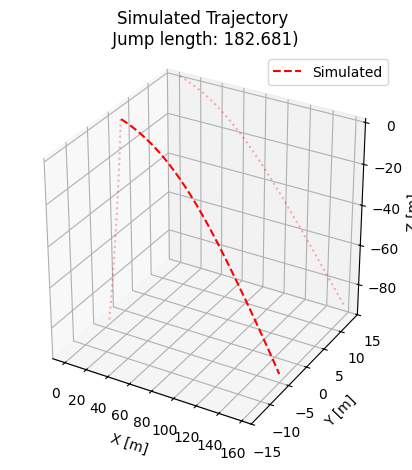

In [60]:
fit_ssm_test(X_list, U_list, Y_list, -29, -3, n_splits=len(X_list), alpha=10)


In [31]:
a = [1]
b = [2]
c = [np.array(a), np.array(b)]
c = np.array(c)
c[0][0] = 4
c[0,0] = 3
c

array([[3],
       [2]])

## z dodanimi kvadrati za veter

In [9]:
#wind_features = ["Speed", "Tangent", "Cross", "Turbulence", 
#   "Speed_quad", "Tangent_quad", "Cross_quad", "Turbulence_quad"]

wind_features = ["Speed", "Tangent", "Cross", "Turbulence"] 

zones = {
    "takeoff": ["W1", "W2", "W3", "W4"],
    "mid":     ["W5", "W6", "W7", "W8"],
    "landing": ["W9", "W10", "W11", "W12"]}

In [10]:

def preprocess_flight_normalized(df, step=0.05):
    """
    Preprocess a normalized flight dataframe (already interpolated) to generate states (X), observations (Y), and controls (U).
    
    Args:
        df (pd.DataFrame): Normalized flight dataframe (fixed time step).
        step (float): Time step between rows (used for derivatives).
        
    Returns:
        states (np.ndarray): State matrix [time_steps, state_dim].
        observations (np.ndarray): Observation matrix [time_steps, obs_dim].
        controls (np.ndarray): Control matrix [time_steps, control_dim].
    """

    df.columns = df.columns.str.strip()   #izloči imena stolpcev
    df = df.iloc[1:]
    
    df = df.ffill().bfill()   #back fill za manjkajoče vrednosti
    
    x = df["X [m]"].to_numpy()   #save values
    y = df["Y [m]"].to_numpy()
    z = df["Z [m]"].to_numpy()
    
    dt = step
    vx = df.get("Speed hor. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)
    vy = np.gradient(y, dt)
    vz = df.get("Speed vert. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    speed = df.get("Speed resulting [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    opening = df.get("Opening Angle [°]", pd.Series([0]*len(x))).to_numpy()
    roll_L = df.get("Roll Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    roll_R = df.get("Roll Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_L = df.get("Yaw Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_R = df.get("Yaw Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    stall_L = df.get("Stalling Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    stall_R = df.get("Stalling Angle Right [°]", pd.Series([0]*len(x))).to_numpy()

    zero = df.get("", pd.Series([0]*len(x))).to_numpy()

    #states = np.stack([x, y, z, vx, vy, vz, speed, opening, roll_L, roll_R, yaw_L, yaw_R, stall_L, stall_R], axis=1)   #zgradimo state vector X
    states = np.stack([x, y, z, speed, opening, roll_L, roll_R, yaw_L, yaw_R, stall_L, stall_R], axis=1)


    height = df.get("Height above ground [m]", pd.Series([0]*len(x))).to_numpy()

    observations = np.stack([x, y, z, height], axis=1)   #zgradimo observation vector Y

    zone_feature_avgs = []
    values = []
    cols = []

    #for feature in wind_features:
    #    for sensor_numb in range(12):
    #        sensor = f"W{sensor_numb + 1}"
    #        cols.append(f"{sensor}_{feature}")
    #        #print(cols)
    #for col in cols:
    #    val = df.get(col, pd.Series([0]*len(x))).to_numpy() 
    #    values.append(val)
    #
    #controls = np.stack(values, axis=1)  # shape: (time_steps, 12)

    #for feature in wind_features:
    #    for zone, sensors in zones.items():
    #        cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
    #        avg_feature = df[cols].mean(axis=1).to_numpy()
    #        zone_feature_avgs.append(avg_feature)
    #
    #controls = np.stack(zone_feature_avgs, axis=1)  # shape: (time_steps, 12)

    for feature in wind_features:
        for zone, sensors in zones.items():
            cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
            avg_feature = df[cols].mean(axis=1).to_numpy()
            zone_feature_avgs.append(avg_feature)
            angles = [speed, opening, roll_L, roll_R, yaw_L, yaw_R, stall_L, stall_R]
    for feat in angles:
        zone_feature_avgs.append(feat)
    
    controls = np.stack(zone_feature_avgs, axis=1)
    
    return states, observations, controls


In [11]:
import os
import pandas as pd
import numpy as np

normalized_folder = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\simulation\2024_03_Planica_12_winds\cleaned\cleaned_quad\normalized_quad'
combined_output = os.path.join(normalized_folder, "combined_dataset.npz")
file_names = []

X_list, Y_list, U_list = [], [], []

for filename in os.listdir(normalized_folder):
    if filename.endswith('.csv'):
        file_path = os.path.join(normalized_folder, filename)
        df = pd.read_csv(file_path)

        X_state, Y_obs, U_ctrl = preprocess_flight_normalized(df)

        X_list.append(X_state)
        Y_list.append(Y_obs)
        U_list.append(U_ctrl)
        file_names.append(filename)

        #if np.any(np.isnan(X_state)):
        #    print(f"NaN values in {filename}")

        print(f"Processed {filename} -> X:{X_state.shape}, Y:{Y_obs.shape}, U:{U_ctrl.shape}")

# Save combined dataset
#np.savez(combined_output, X=np.array(X_list, dtype=object), Y=np.array(Y_list, dtype=object), U=np.array(U_list, dtype=object))
print(f"\nCombined dataset saved to {combined_output}")


Processed 999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(133, 11), Y:(133, 4), U:(133, 20)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102742_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(129, 11), Y:(129, 4), U:(129, 20)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102831_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(142, 11), Y:(142, 4), U:(142, 20)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102832_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(135, 11), Y:(135, 4), U:(135, 20)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102833_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(132, 11), Y:(132, 4), U:(132, 20)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102834_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(131, 11), Y:(131, 4), U:(131, 20)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102835_C_OfficialResults_cleaned_quad-cleaned_nor

In [12]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

def fit_ssm_cv_quad(X_list, U_list, Y_list, n_splits=5, alpha=1e-3):
    """
    Fit an SSM model using K-fold cross-validation across jumps.

    Args:
        X_list, U_list, Y_list: lists of arrays (one per jump)
        n_splits (int): number of folds (or = len(X_list) for LOOCV)
        alpha (float): ridge regularization parameter

    Returns:
        avg_train_err, avg_test_err, models (list of (A,B,C,D) per fold)
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_errors, test_errors = [], []
    models = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_list)):
        X_t = np.vstack([seq[:-1] for i, seq in enumerate(X_list) if i in train_idx])
        X_next = np.vstack([seq[1:] for i, seq in enumerate(X_list) if i in train_idx])
        U_t = np.vstack([u[:-1] for i, u in enumerate(U_list) if i in train_idx])
        Y_t = np.vstack([y[:-1] for i, y in enumerate(Y_list) if i in train_idx])

        # Regression [X_next] ~ [X_t | U_t]
        Phi = np.hstack([X_t, U_t])
        ridge = Ridge(alpha=alpha, fit_intercept=False)     #ridge is just MNK z regularizacijo
        ridge.fit(Phi, X_next)
        Theta = ridge.coef_.T

        state_dim = X_t.shape[1]
        #control_dim = U_t.shape[1]
        A = Theta[:state_dim, :].T
        B = Theta[state_dim:, :].T

        # Regression [Y_t] ~ [X_t | U_t]
        Phi_y = np.hstack([X_t, U_t])
        ridge_y = Ridge(alpha=alpha, fit_intercept=False)
        ridge_y.fit(Phi_y, Y_t)
        Theta_y = ridge_y.coef_.T

        obs_dim = Y_t.shape[1]
        C = Theta_y[:state_dim, :].T
        D = Theta_y[state_dim:, :].T

        models.append((A, B, C, D))

        train_errs = []
        for i in train_idx:  #should be one, but just in case
            x0 = X_list[i][0]
            U_seq = U_list[i]
            X_seq = X_list[i]
            
            X_sim = [x0]
            for t in range(len(U_seq)-1):
                x_next = A @ X_sim[-1] + B @ U_seq[t]
                X_sim.append(x_next)
            X_sim = np.array(X_sim)
        
            train_err = error_fun(X_seq[:, :3], X_sim[:, :3])
            train_errs.append(train_err)

        train_errors.append(np.mean(train_errs))

        test_errs = []
        for j in test_idx:
            x0 = X_list[j][0]      
            U_seq = U_list[j]
            X_seq = X_list[j]

            # simulate with learned model
            X_sim = [x0]
            for t in range(len(U_seq)-1):
                x_next = A @ X_sim[-1] + B @ U_seq[t]
                X_sim.append(x_next)
            X_sim = np.array(X_sim)
            
            test_err = error_fun(X_seq[:, :3], X_sim[:, :3])
            test_errs.append(test_err)

            plot(X_seq[:, :3], X_sim[:, :3], j, "14-S3")
        test_errors.append(np.mean(test_errs))

        #print(train_err, np.mean(test_errs))
        print(np.mean(train_errs), np.mean(test_errs))


    return np.mean(train_errors), np.mean(test_errors), models

In [124]:
avg_train_err, avg_test_err, models = fit_ssm_cv_quad(X_list, U_list, Y_list, n_splits=len(X_list), alpha=10)

print("average train error:", avg_train_err)
print("average test error:", avg_test_err)

1.401572207908007 0.8369565354538433
1.3979986697617448 0.7763014406210353
1.3996784364401125 0.7479552489159694
1.393400380066188 1.2910797451033889
1.3975879313628796 1.0376685252669824
1.3875945814087063 2.4252653022014243
1.3954969494940286 1.279386875745382
1.3969452689048767 1.3921021558114766
1.3961490396046616 1.4073639807894132
1.400419004389047 1.003497069131816
1.395954047028034 1.4905042729680733
1.3973853147125503 1.3805659212585735
1.3919902745621204 2.7173969191413385
1.3993736154310359 0.858725174174621
1.3903942705777435 2.466609604898107
1.393569332327183 1.1195774214446674
1.3981925949413723 1.1584724126576071
1.3940046991825072 1.727132300981409
1.3976631968448643 1.4706309359494374
1.399199211586441 0.7299711213691
1.3956569842557314 1.479286945183603
1.3965900935801838 0.9565209656605805
1.3980241643739781 1.711963802618215
1.39899933226241 0.8259771279924921
1.397468378288603 0.8744019388959438
1.3924590452649341 2.5429039262837403
1.4003811735418952 0.5428586812

# shranimo matrike za najboljši model

In [13]:

def build_models(X_list, U_list, Y_list, n_splits=5, alpha=1e-3):
    """
    Build the matrices and arrays for simulation

    Args:
        X_list, U_list, Y_list: lists of arrays (one per jump)
        n_splits (int): number of folds (or = len(X_list) for LOOCV)
        alpha (float): ridge regularization parameter

    Returns:
        the calculated matrices
    """
    #train_errors, test_errors = [], []
    models = []

    #train_idx = [i for i in range(len(X_list) - 1)] #[i for i in range(len(X_list) - 1)]

    # build training data
    X_t = np.vstack([seq[:-1] for i, seq in enumerate(X_list) ])#if i in train_idx])
    X_next = np.vstack([seq[1:] for i, seq in enumerate(X_list) ])#if i in train_idx])
    U_t = np.vstack([u[:-1] for i, u in enumerate(U_list) ])#if i in train_idx])
    Y_t = np.vstack([y[:-1] for i, y in enumerate(Y_list) ])#if i in train_idx])

    # Regression [X_next] ~ [X_t | U_t]
    Phi = np.hstack([X_t, U_t])
    ridge = Ridge(alpha=alpha, fit_intercept=False)     #ridge is just MNK z regularizacijo
    ridge.fit(Phi, X_next)
    Theta = ridge.coef_.T

    state_dim = X_t.shape[1]
    control_dim = U_t.shape[1]
    A = Theta[:state_dim, :].T
    B = Theta[state_dim:, :].T

        # Regression [Y_t] ~ [X_t | U_t]
    Phi_y = np.hstack([X_t, U_t])
    ridge_y = Ridge(alpha=alpha, fit_intercept=False)
    ridge_y.fit(Phi_y, Y_t)
    Theta_y = ridge_y.coef_.T

    obs_dim = Y_t.shape[1]
    C = Theta_y[:state_dim, :].T
    D = Theta_y[state_dim:, :].T

    models = [A, B, C, D]

    return models


In [14]:
def app_sim(X_important, models, sliders=np.zeros(20)):

    A, B, C, D = models[0], models[1], models[2], models[3]
    winds = sliders[0:12]
    angles = sliders[12:]
    x0 = X_important[0]       #initial state...maybe don't adjust
    X_sim = [x0]
    X_coord = [x0[:3]]
    U_seq = []
    file_length = np.shape(X_important)[0]

    for t in range(file_length):
        U_seq.append(winds)
        U_seq.append(angles)

    for t in range(file_length-1):
        x_next = A @ X_sim[-1] + B @ U_seq[t]
        X_sim.append(x_next)
        X_coord.append(x_next[:3])
    X_sim = np.array(X_sim)

    return X_coord

In [15]:
def app_sim_AVGbase(X_important, models, sliders=np.zeros(20)):

    A, B = models[0], models[1]
    winds = sliders[0:12]
    angles = sliders[12:]
    x0 = X_important[0]       #initial state...maybe don't adjust
    X_sim = [x0]
    X_coord = [x0[:3]]
    U_seq = []
    file_length = np.shape(X_important)[0]

    #winds_quad = np.square(winds)

    winds_angles = np.concatenate([winds, angles])
    #winds_angles = np.concatenate([winds, winds_quad, angles])

    for i in range(file_length):
        U_seq.append(winds_angles)
    #print(U_seq)

    for t in range(file_length-1):
        #print(A.shape)
        #print(len(X_sim))
        #print(X_sim[-1].shape)
        #print (B.shape)
        #print(len(U_seq[t]))

        x_next = A @ X_sim[-1] + B @ U_seq[t]
        X_sim.append(x_next)
        X_coord.append(x_next[:3])
    X_sim = np.array(X_sim)

    return X_coord

In [24]:
models = build_models(X_list, U_list, Y_list)

In [25]:
models[0]

array([[ 9.99108261e-01,  3.28031470e-03, -1.23793315e-03,
         7.32794240e-03, -1.06964608e-02, -1.59656092e-03,
        -1.23750343e-03,  2.38039020e-04, -2.23663594e-04,
        -1.11433901e-04,  5.42538612e-05,  7.48758335e-05,
         4.14858385e-04,  1.27241567e-04],
       [-2.05864603e-05,  9.99429885e-01, -2.90379237e-05,
         5.58298432e-05,  5.17209970e-02, -2.94100038e-05,
        -2.97602444e-05,  6.31344027e-06, -2.75170973e-05,
        -2.36660972e-05, -1.37023604e-05,  8.43345730e-06,
         3.95959970e-05, -3.90303179e-05],
       [-4.17914927e-04, -1.59270572e-03,  9.99429056e-01,
        -2.39253785e-05,  4.92684210e-03,  4.88798055e-03,
        -9.79340130e-05, -9.13313697e-05,  2.24701291e-05,
         3.90147975e-05,  1.22826925e-05, -6.07600823e-05,
         2.56020756e-05,  1.98029632e-05],
       [ 9.65042504e-03,  1.74895111e-02,  1.43993240e-02,
         9.32004999e-01, -6.82730009e-02,  3.62453666e-02,
         3.61976581e-02,  1.15668575e-02,  5.

## avg file matrike

In [ ]:
Xa_list, Ya_list, Ua_list = [], [], []

filename = "average_flight_normalized.csv"
df = pd.read_csv(filename)

Xa_state, Ya_obs, Ua_ctrl = preprocess_flight_normalized(df)

print(f"Processed {filename} -> X:{Xa_state.shape}, Y:{Ya_obs.shape}, U:{Ua_ctrl.shape}")

Processed average_flight_normalized.csv -> X:(139, 11), Y:(139, 4), U:(139, 20)


In [17]:
[Xa_state[0][0]][-1]

np.float64(-3.022420139807136)

In [28]:
models[1][0]

array([ 4.45521289e-03, -1.28335466e-03, -7.98053216e-03,  4.13373848e-03,
       -8.50505420e-04, -1.00918332e-03, -1.02741993e-02,  4.69317269e-03,
        5.20648433e-03, -3.11664516e-02, -6.48974780e-02,  2.26740578e-03,
       -1.36735769e-02, -3.71830628e-03,  1.36106804e-02,  1.23604495e-02,
        4.13331218e-03, -1.05569368e-02,  1.81392369e-02,  3.86501142e-03,
       -1.18053208e-02,  5.15538590e-02,  8.06380030e-02,  1.96743051e-03,
       -1.47284232e-03,  2.32279977e-04, -2.27242366e-04, -1.19209506e-04,
        4.84285664e-05,  8.94067270e-05,  4.17232542e-04,  1.22003262e-04])

funkcija / output, ki ga rab Neca

In [19]:
models = build_models(X_list, U_list, Y_list)
X_important = Xa_state
app_sim_AVGbase(X_important, models)

[array([-3.02242014e+00,  9.25463498e-04,  1.67108280e+00]),
 array([-2.41495566e+00, -2.25615286e-04,  1.55426404e+00]),
 array([-2.10713251e+00, -8.51213831e-04,  1.49860951e+00]),
 array([-1.95079793e+00, -1.23080967e-03,  1.47241142e+00]),
 array([-1.87101616e+00, -1.49822904e-03,  1.46039588e+00]),
 array([-1.82990432e+00, -1.71663702e-03,  1.45520135e+00]),
 array([-1.80832056, -0.00191539,  1.45327766]),
 array([-1.7965971 , -0.00210789,  1.45291161]),
 array([-1.78985324, -0.00230013,  1.45327601]),
 array([-1.78562595, -0.00249476,  1.4539713 ]),
 array([-1.7826727 , -0.00269288,  1.45480454]),
 array([-1.78036686, -0.00289495,  1.4556827 ]),
 array([-1.77839245, -0.00310118,  1.4565611 ]),
 array([-1.77659014, -0.00331163,  1.45741851]),
 array([-1.77487956, -0.00352635,  1.45824506]),
 array([-1.77322014, -0.00374536,  1.45903641]),
 array([-1.77159135, -0.00396871,  1.45979087]),
 array([-1.76998275, -0.00419641,  1.46050807]),
 array([-1.76838901, -0.0044285 ,  1.46118826]

In [30]:
state_names = [
    "X [m]", "Y [m]", "Z [m]",
    "Vx [m/s]", "Vy [m/s]", "Vz [m/s]",
    "Speed [m/s]",
    "Opening Angle [°]",
    "Roll Angle Left [°]", "Roll Angle Right [°]",
    "Yaw Angle Left [°]", "Yaw Angle Right [°]",
    "Stalling Angle Left [°]", "Stalling Angle Right [°]"]

In [31]:
control_names = []

for feature in wind_features:
    for zone in zones.keys():
        control_names.append(f"{zone}_{feature}")

angle_control_names = [
    "Speed [m/s]",
    "Opening Angle [°]",
    "Roll Angle Left [°]",
    "Roll Angle Right [°]",
    "Yaw Angle Left [°]",
    "Yaw Angle Right [°]",
    "Stalling Angle Left [°]",
    "Stalling Angle Right [°]" ]

control_names.extend(angle_control_names)

In [ ]:
control_names

['takeoff_Speed',
 'mid_Speed',
 'landing_Speed',
 'takeoff_Tangent',
 'mid_Tangent',
 'landing_Tangent',
 'takeoff_Cross',
 'mid_Cross',
 'landing_Cross',
 'takeoff_Turbulence',
 'mid_Turbulence',
 'landing_Turbulence',
 'takeoff_Speed_quad',
 'mid_Speed_quad',
 'landing_Speed_quad',
 'takeoff_Tangent_quad',
 'mid_Tangent_quad',
 'landing_Tangent_quad',
 'takeoff_Cross_quad',
 'mid_Cross_quad',
 'landing_Cross_quad',
 'takeoff_Turbulence_quad',
 'mid_Turbulence_quad',
 'landing_Turbulence_quad',
 'Speed [m/s]',
 'Opening Angle [°]',
 'Roll Angle Left [°]',
 'Roll Angle Right [°]',
 'Yaw Angle Left [°]',
 'Yaw Angle Right [°]',
 'Stalling Angle Left [°]',
 'Stalling Angle Right [°]']

In [33]:
A, B, C, D = models[0], models[1], models[2], models[3]

A_df = pd.DataFrame(A, index=state_names, columns=state_names)
A_df.to_csv("matrixA_named.csv")

B_df = pd.DataFrame(B, index=state_names, columns=control_names)
B_df.to_csv("matrixB_named.csv")

np.savetxt("matrixC.csv", C, delimiter=",")
np.savetxt("matrixD.csv", D, delimiter=",")
